In [37]:
from darts import TimeSeries
from darts.dataprocessing.transformers import MissingValuesFiller
import pandas as pd
from darts.dataprocessing.transformers import Scaler
from darts.models import TransformerModel

In [28]:
series = TimeSeries.from_csv(
    'data.csv',
    time_col='date',
    value_cols=['price(cny/t)', 'china-output(kg)', 'nonchina-output(kg)', 'nev-sales(amount)', 'wind-energy-index', 'magnet-exports(usd)'], 
    freq= 'MS'
)

print("=== TimeSeries Information ===")
print(f"{series.to_dataframe().info()}")
print('\n')
print("=== Basic Statistics ===")
print(f"{series.to_dataframe().describe().astype(int)}")

=== TimeSeries Information ===
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 120 entries, 2015-08-01 to 2025-07-01
Freq: MS
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   price(cny/t)         120 non-null    float64
 1   china-output(kg)     115 non-null    float64
 2   nonchina-output(kg)  115 non-null    float64
 3   nev-sales(amount)    119 non-null    float64
 4   wind-energy-index    120 non-null    float64
 5   magnet-exports(usd)  119 non-null    float64
dtypes: float64(6)
memory usage: 6.6 KB
None


=== Basic Statistics ===
       price(cny/t)  china-output(kg)  nonchina-output(kg)  nev-sales(amount)  \
count           120               115                  115                119   
mean         547699             38336                 7185             574228   
std          247386             26590                 4983             577911   
min          307500                30    

In [32]:
# MissingValuesFiller로 모든 변수에 PCHIP 보간 적용
filler = MissingValuesFiller()
series_filled = filler.transform(series, method="pchip")

print("=== TimeSeries Information ===")
print(f"{series_filled.to_dataframe().info()}")
print('\n')
print("=== Basic Statistics ===")
print(f"{series_filled.to_dataframe().describe().astype(int)}")

=== TimeSeries Information ===
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 120 entries, 2015-08-01 to 2025-07-01
Freq: MS
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   price(cny/t)         120 non-null    float64
 1   china-output(kg)     120 non-null    float64
 2   nonchina-output(kg)  120 non-null    float64
 3   nev-sales(amount)    120 non-null    float64
 4   wind-energy-index    120 non-null    float64
 5   magnet-exports(usd)  120 non-null    float64
dtypes: float64(6)
memory usage: 6.6 KB
None


=== Basic Statistics ===
       price(cny/t)  china-output(kg)  nonchina-output(kg)  nev-sales(amount)  \
count           120               120                  120                120   
mean         547699             37733                 7056             584942   
std          247386             26553                 4968             587324   
min          307500                30    

In [39]:
target = series_filled['price(cny/t)']
past_cov = series_filled[['china-output(kg)', 'nonchina-output(kg)', 'nev-sales(amount)', 'wind-energy-index', 'magnet-exports(usd)']]

In [42]:
scaler = Scaler()
target = scaler.fit_transform(target)
train, val = target.split_before(pd.Timestamp('2023-08-01'))
print(f"target data = train: {len(train)} records + val: {len(val)} records")

scaler_cov = Scaler()
past_cov = scaler_cov.fit_transform(past_cov)
train_cov, val_cov = past_cov.split_before(pd.Timestamp('2023-08-01'))
print(f"covariates data = train_cov: {len(train_cov)} records + val_cov: {len(val_cov)} records")

target data = train: 96 records + val: 24 records
covariates data = train_cov: 96 records + val_cov: 24 records


In [ ]:
model = TransformerModel(
    input_chunk_length=12,
    output_chunk_length=12,
    n_epochs=100
    )
model.fit(train, past_covariates=train_cov, val_series=val, val_past_covariates=val_cov)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Predicting: 0it [00:00, ?it/s]

<Axes: xlabel='date'>

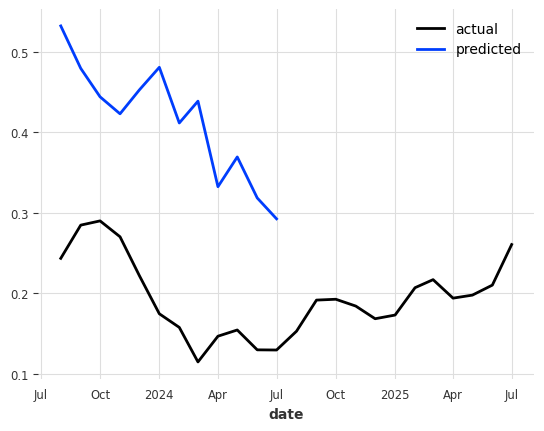

In [ ]:
pred = model.predict(n=12)
val.plot(label='actual')
pred.plot(label='predicted')